<a href="https://colab.research.google.com/github/SakshiMaur/44/blob/main/notebooks/delivery_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

!pip install pandasql

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandasql import sqldf

df = pd.read_csv('Amazon_Logistics_Final_Data.csv')
df.columns = df.columns.str.strip() # Extra spaces hatane ke liye

In [ ]:
# Yahan apna 'is_critical' ya 'is_failed' wala logic dalo
# Is dataset ke hisaab se:
df['is_critical'] = np.where((df['Product_importance'] == 'high') & (df['Customer_rating'] <= 2), 1, 0)
print("Failure/Critical Risk Column Added!")

Failure/Critical Risk Column Added!


In [ ]:
# SQL query for Insights
query = "SELECT Product_importance, COUNT(*) as Total_Orders FROM df GROUP BY Product_importance"
print(sqldf(query, locals()))

  Product_importance  Total_Orders
0               high           948
1                low          5297
2             medium          4754


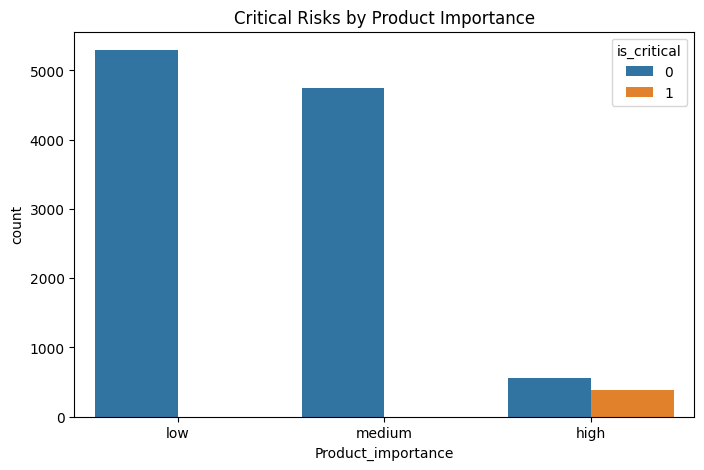

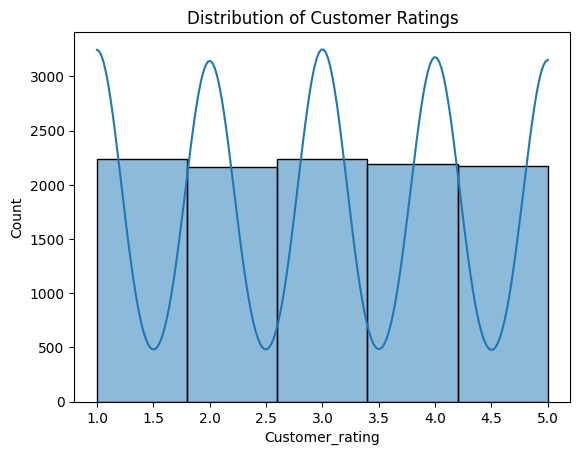

In [ ]:
# Graph 1: Importance vs Criticality
plt.figure(figsize=(8,5))
sns.countplot(x='Product_importance', hue='is_critical', data=df)
plt.title('Critical Risks by Product Importance')
plt.show()

# Graph 2: Distribution of Customer Ratings
sns.histplot(df['Customer_rating'], bins=5, kde=True)
plt.title('Distribution of Customer Ratings')
plt.show()

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. PEHLE columns create karo
df['Warehouse_num'] = df['Warehouse_block'].astype('category').cat.codes
df['Mode_num'] = df['Mode_of_Shipment'].astype('category').cat.codes

# 2. PHIR features (X) define karo
X = df[['Warehouse_num', 'Mode_num']]
y = df['is_critical']

# 3. Model training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 4. Result
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

Final Model Accuracy: 96.82%
